In [ ]:
pip install statsmodels plotly streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 74.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import plotly.graph_objects as go

In [ ]:
!ls

sample_data


In [ ]:
from google.colab import files
files.upload()

Saving Energy_consumption.csv to Energy_consumption.csv


{'Energy_consumption.csv': b'date,energy_kwh,temperature_c,occupancy,is_exam_period\r\n01-10-2025,92,29.1,140,1\r\n02-10-2025,95,29,145,0\r\n03-10-2025,97,28.9,150,1\r\n04-10-2025,90,29.3,135,0\r\n05-10-2025,88,29.5,130,0\r\n06-10-2025,96,29,148,1\r\n07-10-2025,99,28.8,155,1\r\n08-10-2025,101,28.7,160,0\r\n09-10-2025,98,28.9,158,1\r\n10-10-2025,100,28.6,162,0\r\n11-10-2025,94,28.8,150,1\r\n12-10-2025,93,29,148,1\r\n13-10-2025,102,28.5,165,0\r\n14-10-2025,105,28.3,170,0\r\n15-10-2025,108,28.2,175,0\r\n16-10-2025,110,28.1,178,0\r\n17-10-2025,112,27.9,180,0\r\n18-10-2025,109,28,176,1\r\n19-10-2025,107,28.2,172,0\r\n20-10-2025,115,27.8,185,0\r\n21-10-2025,118,27.6,190,0\r\n22-10-2025,120,27.5,195,1\r\n23-10-2025,123,27.4,200,0\r\n24-10-2025,125,27.3,205,0\r\n25-10-2025,122,27.4,198,0\r\n26-10-2025,120,27.6,192,0\r\n27-10-2025,130,27.2,215,1\r\n28-10-2025,135,27,225,1\r\n29-10-2025,138,26.9,235,1\r\n30-10-2025,142,26.8,245,1\r\n31-10-2025,145,26.7,255,1\r\n01-11-2025,148,26.6,265,0\r\n02-11

In [ ]:
import pandas as pd
df = pd.read_csv("Energy_consumption.csv")

In [ ]:
df.head()

,date,energy_kwh,temperature_c,occupancy,is_exam_period
0,01-10-2025,92,29.1,140,1
1,02-10-2025,95,29.0,145,0
2,03-10-2025,97,28.9,150,1
3,04-10-2025,90,29.3,135,0
4,05-10-2025,88,29.5,130,0


<Axes: title={'center': 'Historical Library Energy Usage'}>

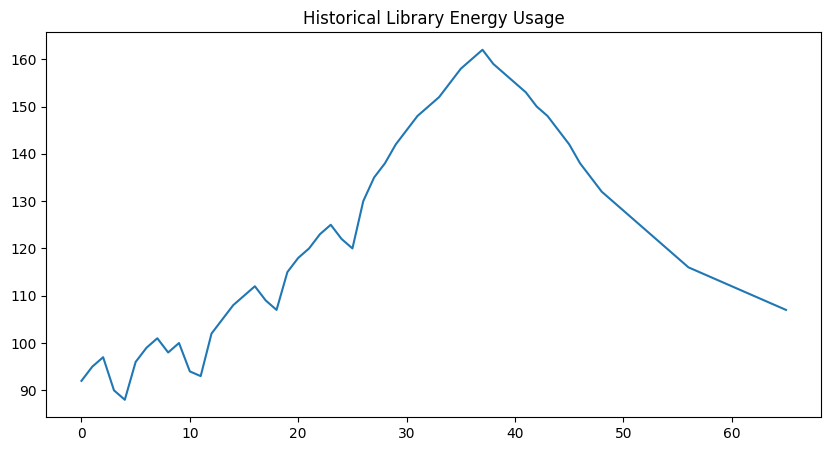

In [ ]:
df["energy_kwh"].plot(title="Historical Library Energy Usage", figsize=(10,5))

In [ ]:
model = ExponentialSmoothing(df["energy_kwh"], trend="add")
fit_model = model.fit()

In [ ]:
forecast_days = 14
forecast = fit_model.forecast(forecast_days)

forecast

,0
66,105.824273
67,104.648545
68,103.472818
69,102.297090
70,101.121363
71,99.945635
72,98.769908
73,97.594180
74,96.418453
75,95.242725


<Axes: title={'center': 'Semester-End Energy Forecast'}>

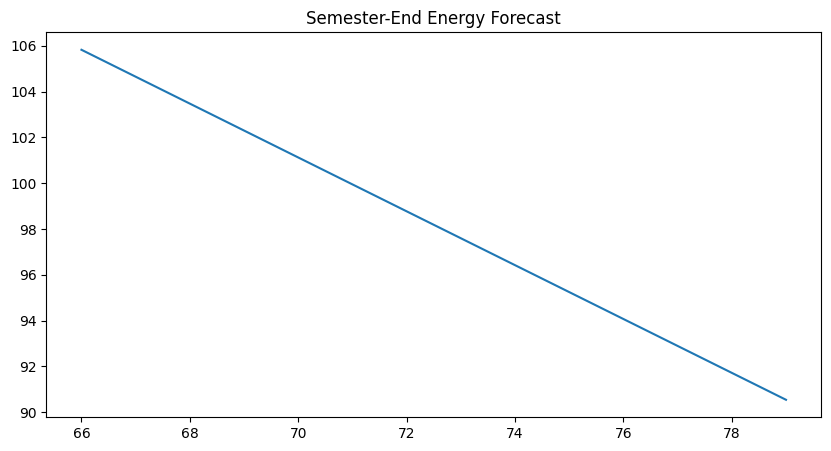

In [ ]:
forecast.plot(title="Semester-End Energy Forecast", figsize=(10,5))

In [ ]:
final_value = round(forecast.iloc[-1], 2)
final_value

np.float64(90.54)

In [ ]:
gauge = go.Figure(go.Indicator(
    mode="gauge+number",
    value=final_value,
    title={"text": "Predicted Energy (kWh)"},
    gauge={
        "axis": {"range": [0, max(df["energy_kwh"]) * 1.3]},
        "bar": {"color": "darkblue"},
        "steps": [
            {"range": [0, 100], "color": "lightgreen"},
            {"range": [100, 150], "color": "orange"},
            {"range": [150, 220], "color": "red"}
        ]
    }
))

gauge

In [ ]:
exam_avg = df[df["is_exam_period"]==1]["energy_kwh"].mean()
non_exam_avg = df[df["is_exam_period"]==0]["energy_kwh"].mean()

exam_avg, non_exam_avg

(np.float64(130.48), np.float64(118.26829268292683))

In [ ]:
model = ExponentialSmoothing(
    df["energy_kwh"],
    trend="add",
    damped_trend=True,
    seasonal="add",
    seasonal_periods=7   # weekly pattern
)

fit_model = model.fit()

<Axes: >

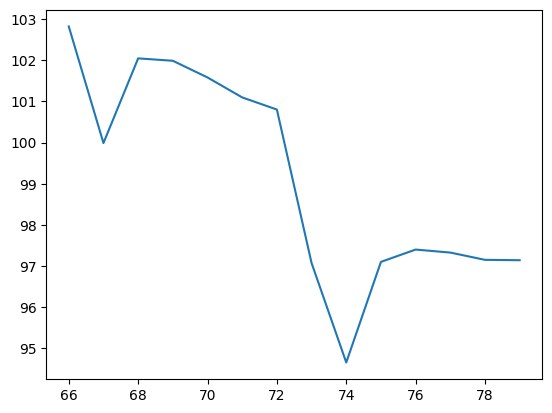

In [ ]:
forecast = fit_model.forecast(14)
forecast.plot()

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(
    df["energy_kwh"],
    trend="add",
    seasonal="add",
    seasonal_periods=7,   # weekly pattern
    damped_trend=True
)

fit_model = model.fit()
forecast = fit_model.forecast(14)

forecast

,0
66,102.822361
67,99.989215
68,102.047312
69,101.988845
70,101.583635
71,101.098649
72,100.803853
73,97.074910
74,94.657970
75,97.102131


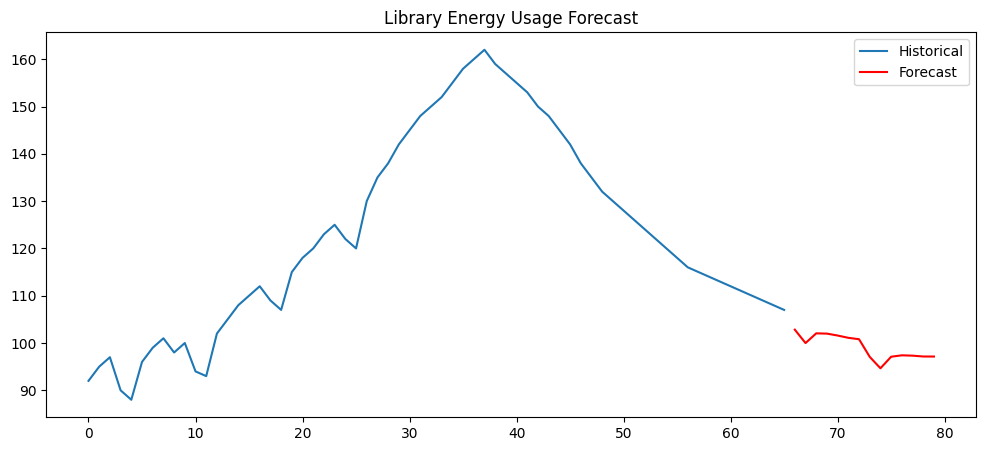

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["energy_kwh"], label="Historical")
plt.plot(forecast, label="Forecast", color="red")
plt.legend()
plt.title("Library Energy Usage Forecast")
plt.show()

In [ ]:
forecast_df = forecast.to_frame(name="forecast_energy_kwh")
forecast_df.to_csv("semester_end_forecast.csv")

forecast_df.head()

,forecast_energy_kwh
66,102.822361
67,99.989215
68,102.047312
69,101.988845
70,101.583635


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

train = df["energy_kwh"][:-14]
test = df["energy_kwh"][-14:]

model_eval = ExponentialSmoothing(train, trend="add").fit()
preds = model_eval.forecast(14)

mae = mean_absolute_error(test, preds)
rmse = np.sqrt(mean_squared_error(test, preds))

mae, rmse

(4.55790071026524, np.float64(5.977979218484894))

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Split data
train = df["energy_kwh"][:-14]
test  = df["energy_kwh"][-14:]

# Train model on training data
model = ExponentialSmoothing(train, trend="add", seasonal=None)
fit = model.fit()

# Predict last 14 days
pred = fit.forecast(14)

# Accuracy metrics
mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))

print("MAE  =", round(mae, 2))
print("RMSE =", round(rmse, 2))

MAE  = 4.56
RMSE = 5.98


In [ ]:
import numpy as np

mape = np.mean(np.abs((test - pred) / test)) * 100
accuracy = 100 - mape

print("MAPE =", round(mape, 2), "%")
print("Accuracy =", round(accuracy, 2), "%")

MAPE = 4.14 %
Accuracy = 95.86 %
